In [ ]:
# Imports
from jiwer import wer, cer
from utils.num_to_words import numbers_to_words
import re
from comet import download_model, load_from_checkpoint
import platform

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import os

import numpy as np
import scipy.stats

# Setup

In [122]:
# Clean text function
def clean_text(text):
    text = re.sub(r"-", " ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = text.lower()
    return text

In [123]:
# Define speakers
speakers = [
    "speaker_1", "speaker_2", "speaker_3", "speaker_4", "speaker_5",
    "speaker_6", "speaker_7", "speaker_8", "speaker_9", "speaker_10"
]

# Define chunk sizes
chunk_sizes = [3000, 3500, 4000, 4500, 5000, 5500, 6000]

# Data Preprocessing 

In [ ]:
# Load COMET model once
model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

def data_results(input_language, output_language):
    # Create an empty DataFrame to store results
    df = pd.DataFrame(columns=['language','chunk_size', 'speaker', 'wer', 'cer', 'comet-score', 'stt_time', 'tt_time', 'tts_time', 'total_time'])
    
    # Iterate over chunk sizes and speakers
    for size in chunk_sizes:
        for speaker in speakers:
            
            # Load data depending on the input language
            if input_language == 'en':
                csv_df = pd.read_csv(f'logs/{speaker}_final_chunk{size}.csv')
            if input_language == 'da':
                csv_df = pd.read_csv(f'logs/dk_{speaker}_chunk{size}.csv')

            # Join all transcriptions and translations into single strings
            model_transcription = ' '.join(csv_df['transcription'].astype(str))
            model_translation = ' '.join(csv_df['translation'].astype(str))

            # Load reference transcriptions and translations
            if input_language == 'en':
                with open(f"data/english/{speaker}_final.txt", "r", encoding="utf-8") as f:
                    ref_transcription = f.read()
                with open(f"data/danish/dk_{speaker}_final.txt", "r", encoding="utf-8") as f:
                    ref_translation = f.read()

            if input_language == 'da':
                with open(f"data/danish/dk_{speaker}_final.txt", "r", encoding="utf-8") as f:
                    ref_transcription = f.read()
                with open(f"data/english/{speaker}_final.txt", "r", encoding="utf-8") as f:
                    ref_translation = f.read()



            # Clean and normalize model and reference transcriptions and translations
            model_transcription = clean_text(model_transcription)
            model_transcription = numbers_to_words(model_transcription, input_language, split_abbreviations=False)

            model_translation = clean_text(model_translation)
            model_translation = numbers_to_words(model_translation, output_language, split_abbreviations=False)

            ref_transcription = clean_text(ref_transcription)
            ref_transcription = numbers_to_words(ref_transcription, input_language, split_abbreviations=False)

            ref_translation = clean_text(ref_translation)
            ref_translation = numbers_to_words(ref_translation, output_language, split_abbreviations=False)

            # Remove filler words from Danish speech to avoid penalizing model
            if input_language == 'da':
                model_transcription = model_transcription.replace('øøhhm', '')
                model_translation = model_translation.replace('uhhm', '')

            # Compute Word Error Rate (WER) and Character Error Rate (CER)
            wer_score = wer(reference=ref_transcription, hypothesis=model_transcription)
            cer_score = cer(reference=ref_transcription, hypothesis=model_transcription)

            # Compute COMET translation quality score
            data = [{
                "src": model_transcription,
                "mt": model_translation,
                "ref": ref_translation
            }]

            if platform.system() == "Darwin":
                num_workers = 1
            else:
                num_workers = 0

            comet_score = comet_model.predict(data, batch_size=1, gpus=0, num_workers=num_workers).scores[0]

            # Extract latency values from CSV logs
            stt_times = csv_df['stt_latency_ms'].tolist()
            tt_times = csv_df['tt_latency_ms'].tolist()
            tts_times = csv_df['tts_latency_ms'].tolist()
            total_times = csv_df['total_latency_ms'].tolist()

            # Append all computed metrics to the results DataFrame
            df.loc[len(df)] = [
                input_language, size, speaker, wer_score, cer_score, comet_score,
                stt_times, tt_times, tts_times, total_times
            ]

    # Specify the folder path to save results
    folder_path = 'results'  

    # Create the folder if it does not already exist
    import os
    os.makedirs(folder_path, exist_ok=True)

    # Save the Dataframe to a CSV file in the specified folder
    df.to_csv(os.path.join(folder_path, f'results_{input_language}.csv'), index=False)

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 51150.05it/s]
Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.1.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../../../../../.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
Encoder model frozen.
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


# Create Dataset

In [126]:
# Use above function to create dataset with English as input and Danish as output
data_results('en', 'da')

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.54s/it]
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doi

In [127]:
# Use above function to create dataset with Danish as input and English as output
data_results('da', 'en')

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.77s/it]
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doi

# Data Visualization

In [ ]:
# Load the results for English input and Danish output
df_en = pd.read_csv("results/results_en.csv")

df_en.head(2)

,language,chunk_size,speaker,wer,cer,comet-score,stt_time,tt_time,tts_time,total_time
0,en,3000,speaker_1,0.181435,0.110599,0.646243,"[638.95, 629.3, 585.22, 663.36, 659.98, 538.74...","[770.81, 1331.01, 1065.7, 1177.26, 1423.59, 11...","[19503.35, 8506.92, 2982.81, 6891.27, 4187.45,...","[27317.51, 32159.37, 32073.88, 35904.86, 36823..."
1,en,3000,speaker_2,0.134483,0.105061,0.790250,"[569.82, 527.66, 492.73, 543.86, 533.52, 543.2...","[431.59, 803.65, 926.18, 922.3, 954.86, 923.66...","[4651.49, 6210.82, 5450.65, 2899.48, 3043.65, ...","[10065.51, 13214.37, 15399.93, 15235.18, 15214..."
2,en,3000,speaker_3,0.182109,0.122665,0.674294,"[531.35, 478.11, 454.33, 532.8, 486.24, 475.44...","[654.73, 816.95, 710.56, 1065.77, 1154.63, 950...","[6668.78, 2018.18, 2090.17, 5009.15, 2487.47, ...","[14445.03, 12983.84, 12014.18, 13548.88, 12767..."
3,en,3000,speaker_4,0.199396,0.131535,0.701204,"[502.36, 572.12, 499.81, 487.0, 489.63, 539.9,...","[536.83, 947.79, 848.8, 909.1, 878.91, 852.0, ...","[6287.88, 6187.89, 3186.4, 3647.08, 2412.84, 2...","[11823.01, 14911.5, 14961.92, 15507.69, 14810...."
4,en,3000,speaker_5,0.088000,0.077403,0.801475,"[548.58, 515.2, 535.76, 587.0, 528.67, 560.73,...","[563.51, 916.41, 1107.92, 1120.97, 799.52, 880...","[8055.59, 5625.49, 6612.3, 3048.43, 2668.77, 2...","[13859.31, 16382.33, 19876.42, 19611.81, 19148..."
...,...,...,...,...,...,...,...,...,...,...
65,en,6000,speaker_6,0.068354,0.046146,0.786708,"[673.17, 4490.49, 628.06, 632.93, 805.04, 703....","[1573.73, 2103.3, 2017.86, 1752.77, 2263.83, 2...","[23159.88, 10658.27, 6128.76, 6279.76, 7242.63...","[26040.39, 30562.92, 30567.76, 30111.82, 31233..."
66,en,6000,speaker_7,0.098266,0.071749,0.742807,"[617.82, 657.94, 541.01, 632.97, 704.94, 539.6...","[1565.28, 1664.62, 1419.12, 1557.24, 1754.02, ...","[18285.89, 5723.28, 4166.65, 5116.7, 9402.78, ...","[21163.0, 20660.16, 18179.51, 17060.14, 20057...."
67,en,6000,speaker_8,0.100000,0.074468,0.832986,"[701.94, 664.49, 624.89, 579.5, 581.41, 615.02...","[1796.13, 1613.85, 1372.85, 1446.4, 1245.17, 1...","[17435.98, 4227.13, 5180.44, 5100.95, 4028.47,...","[20727.89, 18747.92, 17696.38, 16351.98, 14210..."
68,en,6000,speaker_9,0.101333,0.063873,0.778841,"[785.82, 784.0, 784.12, 663.31, 722.91, 714.19...","[1416.36, 1958.33, 2212.42, 2019.92, 2021.99, ...","[19928.43, 6059.72, 21221.12, 5431.76, 7797.83...","[22515.43, 22347.58, 37132.18, 35696.34, 37261..."


In [ ]:
# Load the results for Danish input and English output
df_da = pd.read_csv("results/results_da.csv")

df_da.head(2)

,language,chunk_size,speaker,wer,cer,comet-score,stt_time,tt_time,tts_time,total_time
0,da,3000,speaker_1,0.181435,0.126667,0.687247,"[472.44, 280.61, 75.21, 76.84, 99.02, 72.34, 2...","[466.65, 704.33, 668.64, 568.6, 558.09, 651.22...","[3423.54, 4820.11, 2832.15, 2308.7, 1561.75, 4...","[40007.9, 42789.34, 43381.46, 43658.21, 43181...."
1,da,3000,speaker_2,0.115242,0.093933,0.742452,"[368.37, 256.46, 111.08, 234.41, 72.6, 291.3, ...","[398.89, 695.03, 736.05, 737.84, 716.83, 657.7...","[3340.24, 8436.08, 2571.34, 2663.2, 2519.91, 2...","[37883.6, 43671.81, 43785.25, 44200.83, 44685...."
2,da,3000,speaker_3,0.210356,0.145683,0.704046,"[377.49, 285.77, 111.79, 252.38, 285.66, 72.54...","[452.7, 726.87, 687.59, 579.2, 615.9, 595.5, 6...","[3024.19, 4699.18, 1524.33, 4930.83, 1989.01, ...","[36829.68, 39460.83, 38927.52, 41140.97, 41058..."
3,da,3000,speaker_4,0.087349,0.093873,0.746318,"[392.53, 279.0, 239.8, 263.66, 272.92, 246.86,...","[469.48, 639.58, 690.89, 801.73, 862.09, 709.9...","[5098.79, 8085.5, 2373.07, 2995.75, 2491.17, 2...","[39596.51, 45001.01, 45076.02, 45787.0, 45565...."
4,da,3000,speaker_5,0.191304,0.149837,0.717360,"[363.17, 252.04, 74.18, 105.74, 277.19, 78.12,...","[455.53, 433.08, 551.47, 631.43, 623.76, 639.5...","[3526.25, 2772.15, 2936.94, 1952.89, 2023.71, ...","[37505.45, 38203.24, 38862.99, 38763.06, 38302..."
...,...,...,...,...,...,...,...,...,...,...
65,da,6000,speaker_6,0.121693,0.072597,0.811493,"[386.5, 319.68, 142.38, 168.72, 147.35, 157.14...","[845.58, 953.06, 901.6, 991.25, 999.94, 861.44...","[9114.19, 3759.31, 4369.95, 6455.42, 5657.05, ...","[39626.86, 38189.75, 37175.53, 38407.2, 38881...."
66,da,6000,speaker_7,0.125000,0.066948,0.775906,"[430.3, 328.83, 292.01, 298.5, 332.49, 161.71,...","[714.41, 1072.07, 1159.19, 1120.86, 1205.09, 1...","[9138.23, 6757.76, 5546.13, 5429.2, 6688.02, 1...","[40369.75, 41608.57, 42054.85, 41758.47, 43344..."
67,da,6000,speaker_8,0.102041,0.070119,0.791830,"[463.57, 278.32, 147.68, 180.19, 140.87, 334.3...","[1100.84, 1167.19, 1224.39, 1141.77, 897.7, 97...","[9229.59, 6937.42, 8411.98, 4090.08, 4406.71, ...","[40563.37, 42401.83, 45707.87, 44687.64, 43797..."
68,da,6000,speaker_9,0.113402,0.080019,0.788031,"[465.03, 312.04, 163.96, 126.58, 149.33, 130.8...","[754.84, 872.99, 924.23, 1106.36, 906.0, 930.7...","[8129.62, 4652.37, 6337.29, 37103.74, 3682.18,...","[39404.0, 38948.44, 40185.17, 71979.31, 70566...."


## Plot for each STT, TT, TTS showing each author

In [23]:
def plot_latency_metrics_by_speaker(dataset):
    # Load CSV and parse stringified list columns
    df = pd.read_csv(dataset)
    for col in ['stt_time', 'tt_time', 'tts_time']:
        df[col] = df[col].apply(ast.literal_eval)

    # Get language from first row for plot titles
    language = df['language'].iloc[0].upper()    # Capitalize for nice display

    # Set Seaborn style globally
    sns.set(style="whitegrid")

    # Manually define speaker order, othervise it will be sorted alphabetically (speaker_1, speaker_10, speaker_2 etc.)
    sorted_speakers = [
        'speaker_1', 'speaker_2', 'speaker_3', 'speaker_4', 'speaker_5',
        'speaker_6', 'speaker_7', 'speaker_8', 'speaker_9', 'speaker_10'
    ]

    # Iterate over each latency type
    for latency_type in ['stt_time', 'tt_time', 'tts_time']:
        # Explode the list column
        df_exploded = df.copy()
        df_exploded = df_exploded.explode(latency_type)
        df_exploded[latency_type] = df_exploded[latency_type].astype(float)

        # Group by chunk size and speaker
        grouped_mean = df_exploded.groupby(["chunk_size", "speaker"])[latency_type].mean().reset_index()
        grouped_std = df_exploded.groupby(["chunk_size", "speaker"])[latency_type].std().reset_index()
        grouped = pd.merge(grouped_mean, grouped_std, on=["chunk_size", "speaker"], suffixes=('_mean', '_std'))

        # Create plot
        plt.figure(figsize=(10, 6))

        # Plot using your manual order
        for speaker in sorted_speakers:
            if speaker not in grouped["speaker"].values:
                continue  # Skip if speaker not in data
            speaker_data = grouped[grouped["speaker"] == speaker]
            sns.lineplot(
                data=speaker_data,
                x="chunk_size",
                y=f"{latency_type}_mean",
                marker="o",
                label=speaker
            )
            plt.fill_between(
                speaker_data["chunk_size"],
                speaker_data[f"{latency_type}_mean"] - speaker_data[f"{latency_type}_std"],
                speaker_data[f"{latency_type}_mean"] + speaker_data[f"{latency_type}_std"],
                alpha=0.2
            )

        # Axis range suggestions
        y_limits = {
            'stt_time': (0, 2500),
            'tt_time': (0, 2250),
            'tts_time': (0, 12500)
        }
        plt.ylim(y_limits[latency_type])

        # Labels and layout
        label = latency_type.upper().replace('_TIME', '')
        plt.xlabel("Chunk Size (ms)")
        plt.ylabel(f"Average {label} Time (ms)")
        plt.title(f"Average {label} Time per Speaker by Chunk Size ({language})")

        # Sort legend using same order
        handles, labels = plt.gca().get_legend_handles_labels()
        legend_order = [label for label in sorted_speakers if label in labels]
        sorted_handles = [handles[labels.index(l)] for l in legend_order]
        plt.legend(sorted_handles, legend_order, title="Speaker", bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.grid(True)
        plt.show()

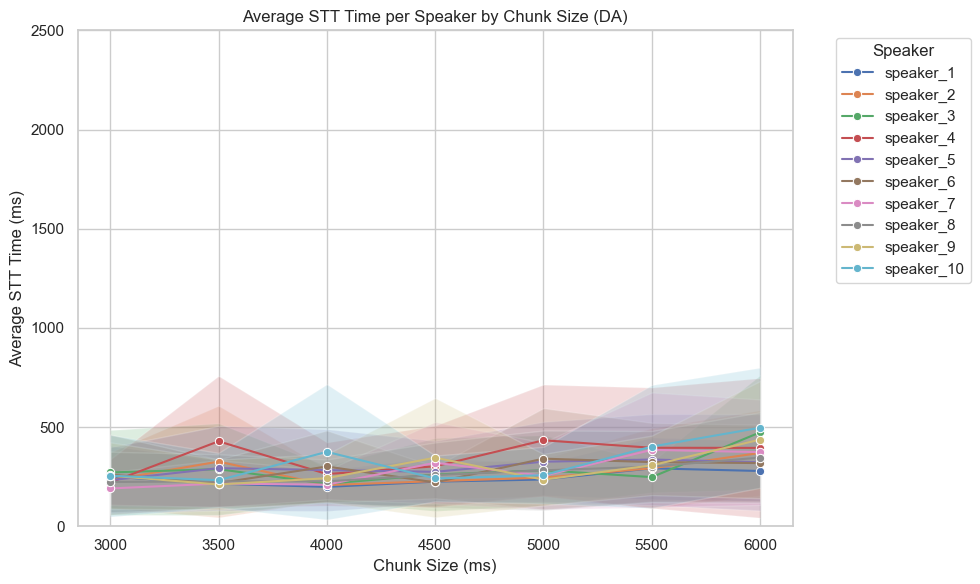

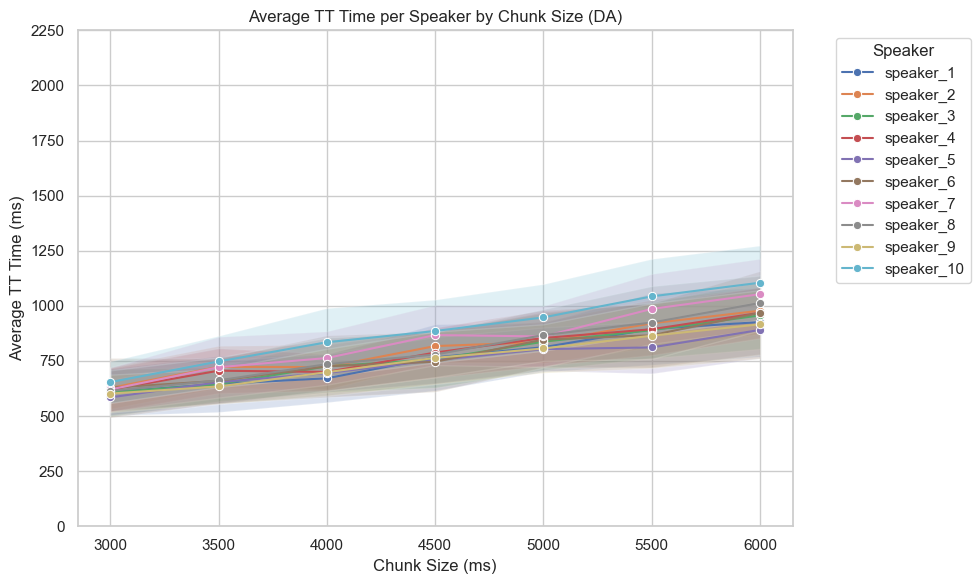

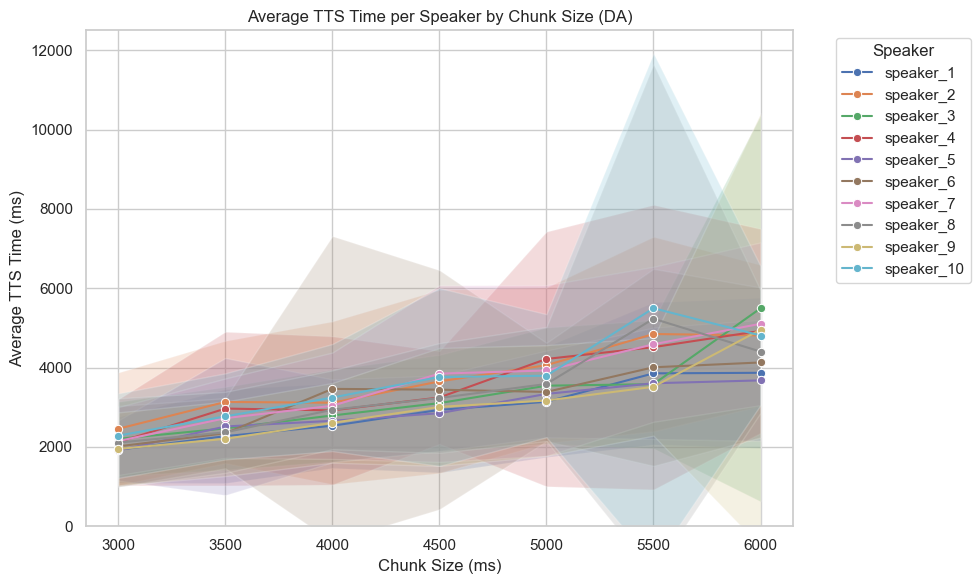

In [24]:
# Plot latency metrics for Danish input and English output
plot_latency_metrics_by_speaker("results/results_da.csv")

In [ ]:
# Plot latency metrics for English input and Danish output
plot_latency_metrics_by_speaker("results/results_en.csv")

## Plot for each STT, TT, TTS showing average

In [20]:
def plot_avg_latency_by_chunk_size(dataset):
    # Load CSV
    df = pd.read_csv(dataset)

    # Get language from first row
    language = df['language'].iloc[0].upper()  # Capitalize for nice display

    # Convert stringified lists to actual lists
    for col in ['stt_time', 'tt_time', 'tts_time']:
        df[col] = df[col].apply(ast.literal_eval)

    # Compute average latencies per row
    df['avg_stt_time'] = df['stt_time'].apply(lambda x: sum(x) / len(x))
    df['avg_tt_time'] = df['tt_time'].apply(lambda x: sum(x) / len(x))
    df['avg_tts_time'] = df['tts_time'].apply(lambda x: sum(x) / len(x))

    # Group by chunk size and compute mean across speakers
    grouped = df.groupby('chunk_size')[['avg_stt_time', 'avg_tt_time', 'avg_tts_time']].mean().reset_index()

    # Plot
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    sns.lineplot(data=grouped, x='chunk_size', y='avg_stt_time', marker='o', label='STT Time')
    sns.lineplot(data=grouped, x='chunk_size', y='avg_tt_time', marker='o', label='TT Time')
    sns.lineplot(data=grouped, x='chunk_size', y='avg_tts_time', marker='o', label='TTS Time')

    plt.title(f'Average STT, TT, and TTS Time vs Chunk Size ({language})')

    plt.ylim(0, 7000)  # Set Y-axis range for STT
    plt.ylabel('Time (ms)')
    plt.xlabel('Chunk Size (ms)')
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.show()

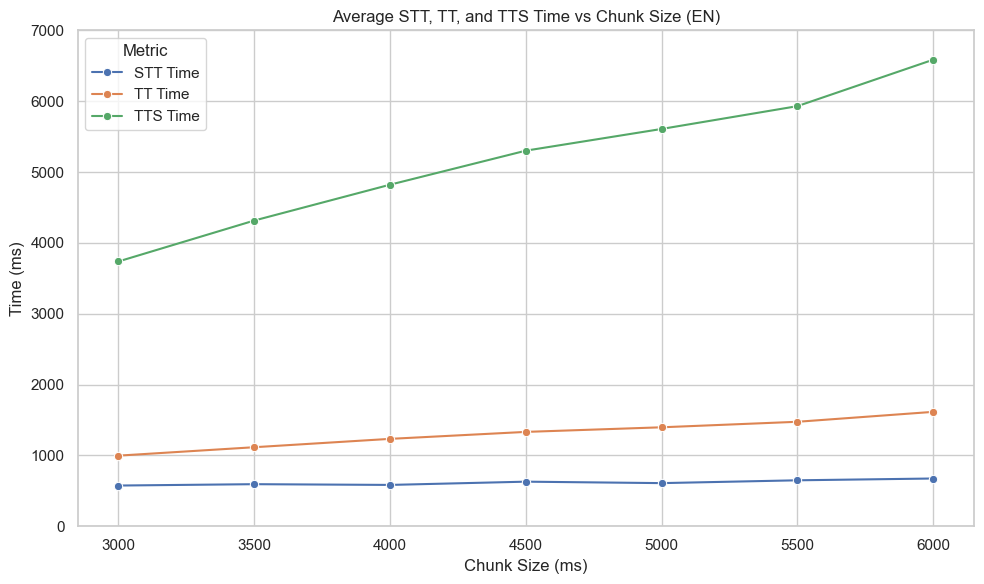

In [21]:
# Plot average latency by chunk size for English input and Danish output
plot_avg_latency_by_chunk_size("results/results_en.csv")

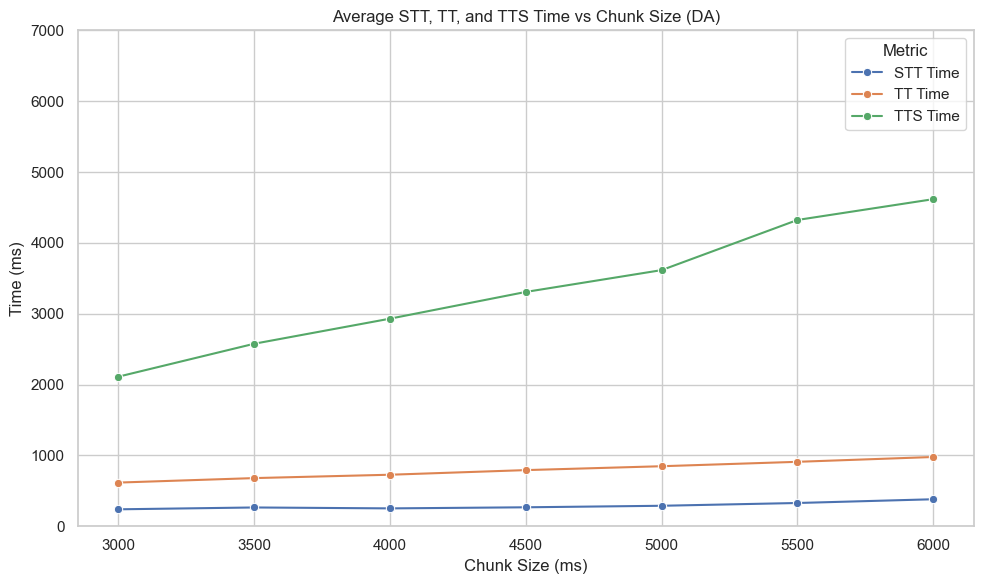

In [22]:
# Plot average latency by chunk size for Danish input and English output
plot_avg_latency_by_chunk_size("results/results_da.csv")

## Plot CER and WER

In [6]:
def plot_wer_cer_by_chunk_and_language(danish_csv, english_csv):
    # Load both CSVs
    df_da = pd.read_csv(danish_csv)
    df_en = pd.read_csv(english_csv)

    # Compute average WER and CER per chunk size
    grouped_da = df_da.groupby('chunk_size')[['wer', 'cer']].mean().reset_index()
    grouped_en = df_en.groupby('chunk_size')[['wer', 'cer']].mean().reset_index()

    # Set seaborn style
    sns.set(style="whitegrid")

    # Plot
    plt.figure(figsize=(10, 6))

    # Danish
    sns.lineplot(data=grouped_da, x='chunk_size', y='wer', color='red', label='Danish WER', marker='o')
    sns.lineplot(data=grouped_da, x='chunk_size', y='cer', color='lightcoral', label='Danish CER', marker='o')

    # English
    sns.lineplot(data=grouped_en, x='chunk_size', y='wer', color='navy', label='English WER', marker='o')
    sns.lineplot(data=grouped_en, x='chunk_size', y='cer', color='skyblue', label='English CER', marker='o')

    # Labels and legend
    plt.title('WER and CER per Chunk Size (Danish vs English)')
    plt.xlabel('Chunk Size')
    plt.ylabel('Error Rate')
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.show()

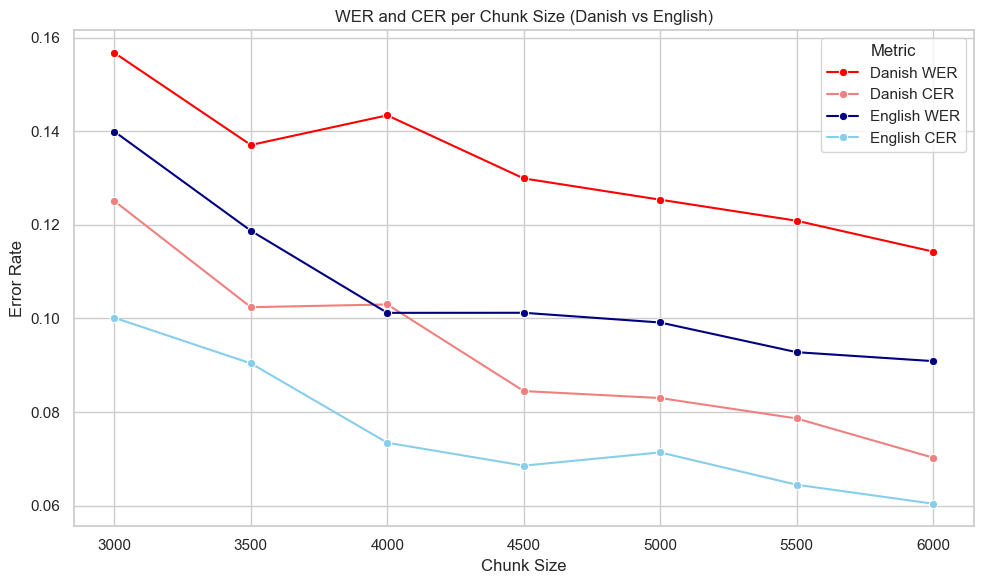

In [8]:
# Plot WER and CER by chunk size for both Danish and English
plot_wer_cer_by_chunk_and_language("results/results_da.csv", "results/results_en.csv")

## Plot COMET

In [7]:
def plot_comet_by_chunk_and_language(danish_csv, english_csv):
    # Load both CSVs
    df_da = pd.read_csv(danish_csv)
    df_en = pd.read_csv(english_csv)

    # Compute average WER and CER per chunk size
    grouped_da = df_da.groupby('chunk_size')[['comet-score']].mean().reset_index()
    grouped_en = df_en.groupby('chunk_size')[['comet-score']].mean().reset_index()

    # Set seaborn style
    sns.set(style="whitegrid")

    # Plot
    plt.figure(figsize=(10, 6))


    sns.lineplot(data=grouped_da, x='chunk_size', y='comet-score', color='red', label='Danish to English', marker='o')

    sns.lineplot(data=grouped_en, x='chunk_size', y='comet-score', color='navy', label='English to Danish', marker='o')

    # Labels and legend
    plt.title('Comet-score per Chunk Size (Danish vs English)')
    plt.xlabel('Chunk Size')
    plt.ylabel('Comet Score')
    plt.legend(title='Metric')
    plt.tight_layout()

    plt.show()

In [ ]:
# Plot COMET scores by chunk size for both Danish and English
plot_comet_by_chunk_and_language("results/results_da.csv", "results/results_en.csv")

## Plot latency for one random chunk size and speaker

In [115]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re

def plot_total_latency_one_sample(dataset):
    # Load CSV
    df = pd.read_csv(dataset)

    # Extract filename
    filename = os.path.basename(dataset).lower()

    # Determine language
    language = "DA" if "dk_" in filename else "EN"

    # Extract speaker number
    speaker_match = re.search(r"speaker_(\d+)", filename)
    speaker_num = speaker_match.group(1) if speaker_match else "Unknown"

    # Extract chunk size
    chunk_match = re.search(r"chunk(\d+)", filename)
    chunk_size = chunk_match.group(1) if chunk_match else "Unknown"

    # Add chunk index for x-axis
    df['chunk_index'] = range(len(df))

    # Plotting
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    sns.lineplot(data=df, x='chunk_index', y='total_latency_ms', marker='o', color='red', label='Total Latency')
    sns.lineplot(data=df, x='chunk_index', y='stt_latency_ms', marker='o', color='blue', label='STT Latency')
    sns.lineplot(data=df, x='chunk_index', y='tt_latency_ms', marker='o', color='green', label='TT Latency')
    sns.lineplot(data=df, x='chunk_index', y='tts_latency_ms', marker='o', color='orange', label='TTS Latency')

    # Title with all info
    plt.title(f'Latency per Chunk - Speaker: {speaker_num}, Chunk Size: {chunk_size} ({language})')
    plt.xlabel('Chunk Number')
    plt.ylabel('Latency (ms)')
    plt.legend()
    plt.tight_layout()
    plt.show()


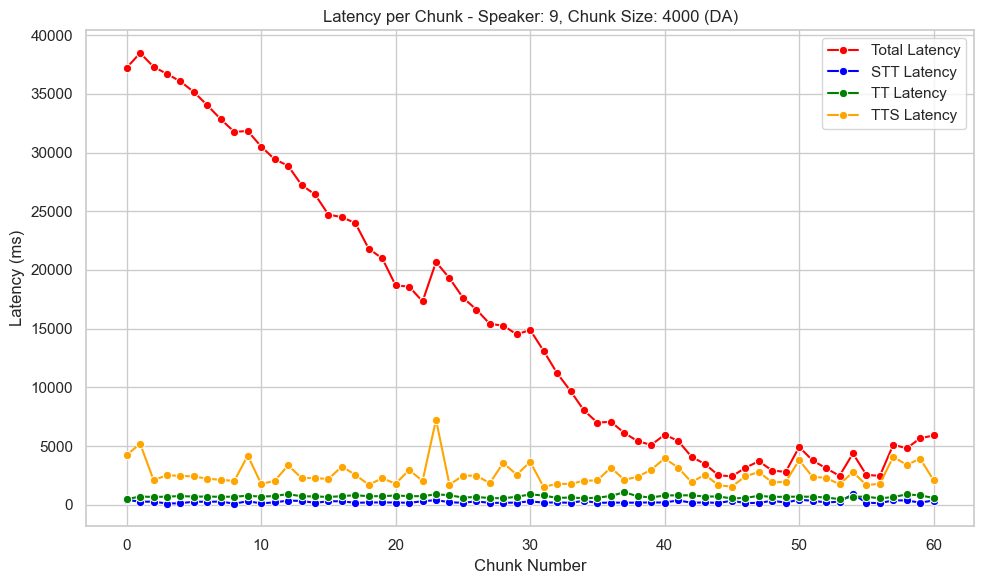

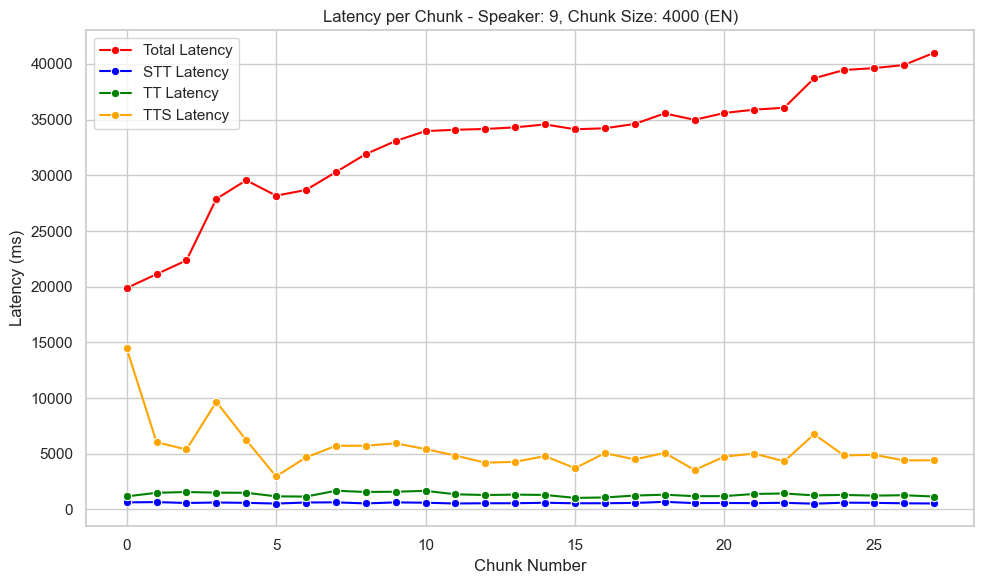

(None, None)

In [116]:
plot_total_latency_one_sample("logs/dk_speaker_9_chunk4000.csv"), plot_total_latency_one_sample("logs/speaker_9_final_chunk4000.csv"), 

## Save all plots to folder

In [15]:
# Ensure the "images" folder exists
os.makedirs("images", exist_ok=True)

# Backup the original plt.show function
_original_show = plt.show

# Counter to give unique filenames
_plot_counter = 0

def save_figs_to_folder():
    # Override plt.show to save plots instead of displaying them.
    def _save_and_close(*args, **kwargs):
        global _plot_counter
        filename = f"images/plot_{_plot_counter:02d}.png"
        plt.savefig(filename, bbox_inches='tight')
        plt.close()
        _plot_counter += 1
    plt.show = _save_and_close

def restore_show():
    # Restore the original plt.show behavior.
    plt.show = _original_show

# Apply the override
save_figs_to_folder()

# Call your functions as-is
plot_latency_metrics_by_speaker("results/results_en.csv")
plot_latency_metrics_by_speaker("results/results_da.csv")
plot_avg_latency_by_chunk_size("results/results_en.csv")
plot_avg_latency_by_chunk_size("results/results_da.csv")
plot_wer_cer_by_chunk_and_language("results/results_da.csv", "results/results_en.csv")
plot_comet_by_chunk_and_language("results/results_da.csv", "results/results_en.csv")

# Restore normal behavior if needed
restore_show()


## Statistics

In [8]:
# Compute Margin of Error (ME) on given data using bootstrap
def compute_ME(data):
    data = np.asarray(data)
    
    # Compute bootstrap confidence intervals
    bounds = scipy.stats.bootstrap((data,), np.mean)
    
    # Extract lower and upper bounds of the confidence interval
    cil, ciu = bounds.confidence_interval
    
    # Calculate the margin of error as the max distance from the mean to the confidence interval bounds
    margin_error = np.mean(data)-cil if np.mean(data)-cil > ciu-np.mean(data) else ciu-np.mean(data)
    return margin_error
    

def compute_statistics(dataset):
    df = pd.read_csv(dataset)

    # Ensure timing columns are converted from stringified lists to numerical arrays
    def parse_and_flatten(col):
        return df[col].apply(ast.literal_eval).explode().astype(float)

    # Group by chunk_size
    chunk_sizes = [3000, 3500, 4000, 4500, 5000, 5500, 6000]
    results = []

    # Iterate over each chunk size
    for chunk_size in chunk_sizes:
        chunk_df = df[df['chunk_size'] == chunk_size]

        # Skip if there is no data for this chunk size
        if chunk_df.empty:
            continue
        
        # Compute statistics for WER, CER and COMET
        wer_mean = chunk_df['wer'].mean()
        wer_margin = compute_ME(chunk_df['wer'])

        cer_mean = chunk_df['cer'].mean()
        cer_margin = compute_ME(chunk_df['cer'])

        comet_mean = chunk_df['comet-score'].mean()
        comet_margin = compute_ME(chunk_df['comet-score'])

        # Parse and compute mean and margin of error for STT latency
        stt_times = parse_and_flatten('stt_time')[df['chunk_size'] == chunk_size]
        stt_mean = stt_times.mean()
        stt_margin = compute_ME(stt_times)

        # Parse and compute mean and margin of error for TT latency
        tt_times = parse_and_flatten('tt_time')[df['chunk_size'] == chunk_size]
        tt_mean = tt_times.mean()
        tt_margin = compute_ME(tt_times)

        # Parse and compute mean and margin of error for TTS latency
        tts_times = parse_and_flatten('tts_time')[df['chunk_size'] == chunk_size]
        tts_mean = tts_times.mean()
        tts_margin = compute_ME(tts_times)

        # Parse and compute mean and margin of error for total latency
        total_times = parse_and_flatten('total_time')[df['chunk_size'] == chunk_size]
        total_mean = total_times.mean()
        total_margin = compute_ME(total_times)

        # Append formatted metrics to results list
        results.append({
            "Chunk Size": chunk_size,
            "WER ": f"{wer_mean:.3f} ± {wer_margin:.3f}",
            "CER ": f"{cer_mean:.3f} ± {cer_margin:.3f}",
            "COMET": f"{comet_mean:.3f} ± {comet_margin:.3f}",
            "Avg STT Time (ms)": f"{stt_mean:.2f} ± {stt_margin:.2f}",
            "Avg TT Time (ms)": f"{tt_mean:.2f} ± {tt_margin:.2f}",
            "Avg TTS Time (ms)": f"{tts_mean:.2f} ± {tts_margin:.2f}",
            "Avg Total Latency (ms)": f"{total_mean:.2f} ± {total_margin:.2f}"
        })

    # Return the results as a DataFrame
    return pd.DataFrame(results)

    # If you want to display it interactively in some contexts:
    #import ace_tools as tools; tools.display_dataframe_to_user(name="Latency and Error Statistics by Chunk Size", dataframe=result_df)

In [9]:
# Compute and display statistics for Danish input and English output
compute_statistics("results/results_da.csv")

,Chunk Size,WER,CER,COMET,Avg STT Time (ms),Avg TT Time (ms),Avg TTS Time (ms),Avg Total Latency (ms)
0,3000,0.157 ± 0.026,0.125 ± 0.013,0.727 ± 0.018,239.98 ± 13.42,615.63 ± 7.62,2098.31 ± 79.18,31776.79 ± 846.58
1,3500,0.137 ± 0.020,0.102 ± 0.013,0.751 ± 0.021,264.10 ± 18.15,676.68 ± 8.99,2552.08 ± 121.26,32564.13 ± 1068.50
2,4000,0.143 ± 0.027,0.103 ± 0.014,0.747 ± 0.034,255.55 ± 17.07,726.49 ± 11.05,2926.70 ± 213.40,31715.14 ± 1173.53
3,4500,0.130 ± 0.028,0.084 ± 0.013,0.761 ± 0.034,270.09 ± 19.22,789.14 ± 12.36,3283.45 ± 203.06,27319.61 ± 1221.76
4,5000,0.125 ± 0.016,0.083 ± 0.010,0.769 ± 0.021,291.50 ± 21.38,845.93 ± 13.00,3592.76 ± 213.96,28416.85 ± 1460.76
5,5500,0.121 ± 0.024,0.079 ± 0.013,0.776 ± 0.021,328.29 ± 25.40,904.58 ± 17.18,4277.91 ± 496.69,31040.21 ± 1856.83
6,6000,0.114 ± 0.016,0.070 ± 0.009,0.775 ± 0.036,382.02 ± 32.43,973.44 ± 17.69,4598.74 ± 453.68,32803.14 ± 1801.65


In [11]:
# Compute and display statistics for English input and Danish output

compute_statistics("results/results_en.csv")

,Chunk Size,WER,CER,COMET,Avg STT Time (ms),Avg TT Time (ms),Avg TTS Time (ms),Avg Total Latency (ms)
0,3000,0.140 ± 0.023,0.100 ± 0.011,0.744 ± 0.037,574.97 ± 133.11,997.49 ± 18.69,3737.42 ± 193.20,22426.24 ± 783.94
1,3500,0.119 ± 0.030,0.090 ± 0.015,0.750 ± 0.032,592.31 ± 90.65,1116.38 ± 22.26,4317.88 ± 227.74,22510.54 ± 1066.39
2,4000,0.101 ± 0.019,0.073 ± 0.015,0.759 ± 0.034,584.11 ± 83.86,1234.32 ± 29.13,4826.86 ± 257.98,23137.58 ± 1282.81
3,4500,0.101 ± 0.016,0.069 ± 0.010,0.762 ± 0.032,628.98 ± 101.25,1331.94 ± 28.59,5302.12 ± 331.36,21801.69 ± 1264.91
4,5000,0.099 ± 0.027,0.071 ± 0.018,0.766 ± 0.039,609.02 ± 28.46,1397.79 ± 33.48,5609.80 ± 372.51,19171.39 ± 743.08
5,5500,0.093 ± 0.017,0.064 ± 0.013,0.767 ± 0.034,648.69 ± 53.71,1476.94 ± 35.95,5933.67 ± 490.98,60947.38 ± 2352.45
6,6000,0.091 ± 0.017,0.060 ± 0.006,0.768 ± 0.043,673.95 ± 88.07,1615.20 ± 43.65,6585.63 ± 541.81,48521.91 ± 10170.66


## Average of one/more files

In [129]:
import pandas as pd

def average():
    # datasets = [
    #     "logs/speaker_3_final_chunk6000.csv", 
    #     "logs/speaker_4_final_chunk6000.csv", 
    #     "logs/speaker_5_final_chunk6000.csv",
    #     "logs/speaker_6_final_chunk6000.csv",
    #     "logs/speaker_7_final_chunk6000.csv",
    #     "logs/speaker_8_final_chunk6000.csv",
    #     "logs/speaker_9_final_chunk6000.csv",
    #     "logs/speaker_10_final_chunk6000.csv"
    # ]
    
    datasets = ["logs/speaker_10_final_chunk5500.csv"]

    total_latency = 0
    total_count = 0

    for file in datasets:
            df = pd.read_csv(file)
            total_latency += df["total_latency_ms"].sum()
            total_count += df["total_latency_ms"].count()


    avg_latency = total_latency / total_count
    return f"Average total latency for chunk 6000 is {avg_latency:.2f} ms"


In [130]:
print(average())


Average total latency for chunk 6000 is 21591.10 ms
